<a href="https://colab.research.google.com/github/AbdullahAlbadri/Fraud-Detection-Research/blob/main/Fraud_research_AutoEncoder_%2B_GraphSAGE_by_Abdullah_Albadri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data calling from google drive

In [35]:
# Cell 1: connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# Cell 2: check the files are there
import os
DATA_DIR = '/content/drive/MyDrive/fraud_project/data/ieee-fraud-detection'
print(os.listdir(DATA_DIR))

['sample_submission.csv', 'test_identity.csv', 'test_transaction.csv', 'train_identity.csv', 'train_transaction.csv']


#Look into the dataset

In [37]:
# Cell 3: load both tables (takes about a minute)
import pandas as pd

trans = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
ident = pd.read_csv(f'{DATA_DIR}/train_identity.csv')

print('transactions:', trans.shape)
print('identity    :', ident.shape)

transactions: (590540, 394)
identity    : (144233, 41)


In [38]:
# Cell 4: look at the first rows
trans.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
# Cell 5: column types
print(trans.dtypes.value_counts())
print()
print(ident.dtypes.value_counts())

float64    376
object      14
int64        4
Name: count, dtype: int64

float64    23
object     17
int64       1
Name: count, dtype: int64


In [40]:
# Cell 6: merge the two tables and sort by time
df = trans.merge(ident, on='TransactionID', how='left')
df = df.sort_values('TransactionDT', kind='stable').reset_index(drop=True)
del trans, ident   # free memory

print(df.shape)
print('rows with identity info:', f"{df['id_01'].notna().mean():.1%}")

(590540, 434)
rows with identity info: 24.4%


fraud rate: 3.50%  (20,663 of 590,540)


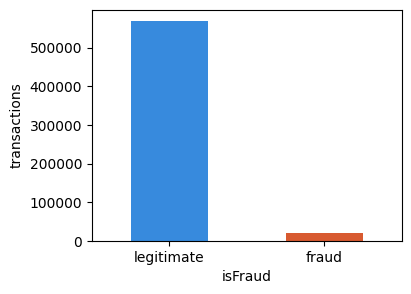

In [41]:
# Cell 7: class balance
import matplotlib.pyplot as plt
import numpy as np

print(f"fraud rate: {df['isFraud'].mean():.2%}  ({df['isFraud'].sum():,} of {len(df):,})")
df['isFraud'].value_counts().plot(kind='bar', color=['#378ADD', '#D85A30'], figsize=(4, 3))
plt.xticks([0, 1], ['legitimate', 'fraud'], rotation=0)
plt.ylabel('transactions'); plt.show()

#Preprocessing


In [42]:
import numpy as np, pandas as pd, torch
from torch.utils.data import DataLoader, TensorDataset

# df is already sorted by TransactionDT
n = len(df)
i1, i2 = int(0.70 * n), int(0.85 * n)     # train | val | test boundaries (used by BOTH branches)

y = df['isFraud'].values.astype(np.float32)
y_tr, y_va, y_te = y[:i1], y[i1:i2], y[i2:]
print(f"train {i1:,} | val {i2 - i1:,} | test {n - i2:,}")
print(f"fraud rate  train {y_tr.mean():.2%} | val {y_va.mean():.2%} | test {y_te.mean():.2%}")

train 413,378 | val 88,581 | test 88,581
fraud rate  train 3.52% | val 3.43% | test 3.48%


##Preprocessing - AutoEncoder

In [43]:
def preprocess_tabular(df, i1):
    # TransactionDT is only used for sorting; a raw time value would be out of range for later data
    drop = ['TransactionID', 'isFraud', 'TransactionDT']
    feature_cols = [c for c in df.columns if c not in drop]
    cat_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
    num_cols = [c for c in feature_cols if c not in cat_cols]

    X = df[feature_cols].copy()

    # categorical -> integer codes from TRAIN values only (unseen or missing -> 0)
    cat_maps = {}
    for col in cat_cols:
        vals = X[col].iloc[:i1].dropna().unique()
        cat_maps[col] = {v: k + 1 for k, v in enumerate(vals)}
        X[col] = X[col].map(cat_maps[col]).fillna(0)

    # missing numbers -> TRAIN medians
    medians = X[num_cols].iloc[:i1].median()
    X[num_cols] = X[num_cols].fillna(medians)

    # standardize with TRAIN mean / std
    X = X.astype('float32')
    mean = X.iloc[:i1].mean()
    std = X.iloc[:i1].std().replace(0, 1).fillna(1)
    X = ((X - mean) / std).clip(-10, 10)

    X = X.values.astype(np.float32)
    assert not np.isnan(X).any(), 'NaNs left in the features'
    return X, dict(feature_cols=feature_cols, cat_cols=cat_cols, num_cols=num_cols,
                   cat_maps=cat_maps, medians=medians, mean=mean, std=std)

X_all, tab_info = preprocess_tabular(df, i1)
X_tr, X_va, X_te = X_all[:i1], X_all[i1:i2], X_all[i2:]
print('tabular matrix:', X_all.shape)

tabular matrix: (590540, 431)


In [44]:
# Loaders for the autoencoder: legitimate train rows only; val/test keep every row
X_train_legit = torch.tensor(X_tr[y_tr == 0])
train_loader = DataLoader(TensorDataset(X_train_legit), batch_size=512, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_va), torch.tensor(y_va)), batch_size=2048)
test_loader = DataLoader(TensorDataset(torch.tensor(X_te), torch.tensor(y_te)), batch_size=2048)
print('train legit rows:', len(X_train_legit))

train legit rows: 398840


##Preprocessing - GraphSAGE

In [45]:
ENTITY_COLS = ['card1', 'DeviceInfo', 'P_emaildomain', 'addr1']   # agree these with your group

def preprocess_graph(df, i1, entity_cols):
    # Node table from TRAIN values only. Node 0 is reserved for the UNKNOWN node.
    vocab, offset = {}, 1
    for col in entity_cols:
        vals = df[col].iloc[:i1].dropna().unique()
        vocab[col] = {v: offset + k for k, v in enumerate(vals)}
        offset += len(vals)
    num_nodes = offset

    # Node id of each transaction's entities:  unseen -> 0 (UNK),  missing -> -1 (no node)
    ent = np.zeros((len(df), len(entity_cols)), dtype=np.int64)
    for j, col in enumerate(entity_cols):
        raw = df[col]
        ids = raw.map(vocab[col]).fillna(0).astype(np.int64).values
        ent[:, j] = np.where(raw.isna().values, -1, ids)

    # Edges from TRAIN transactions only: connect every pair of entities in the same transaction
    k = len(entity_cols); tr = ent[:i1]
    src, dst = [], []
    for a in range(k):
        for b in range(k):
            if a != b:
                ok = (tr[:, a] >= 0) & (tr[:, b] >= 0)
                src.append(tr[ok, a]); dst.append(tr[ok, b])
    pairs = np.unique(np.concatenate(src) * num_nodes + np.concatenate(dst))   # drop duplicate edges
    edge_index = torch.tensor(np.stack([pairs // num_nodes, pairs % num_nodes]))
    return ent, edge_index, num_nodes, vocab

ent_idx, edge_index, num_nodes, vocab = preprocess_graph(df, i1, ENTITY_COLS)
print('graph:', num_nodes, 'nodes,', edge_index.shape[1], 'directed edges')

graph: 14166 nodes, 192582 directed edges


In [46]:
# Check: how many entities are missing or unseen in val / test?
for j, col in enumerate(ENTITY_COLS):
    for name, sl in (('val', slice(i1, i2)), ('test', slice(i2, None))):
        e = ent_idx[sl, j]; have = e >= 0
        print(f"{col:14s} {name:4s} missing {(~have).mean():5.1%} | unseen among present {(e[have] == 0).mean():5.1%}")

card1          val  missing  0.0% | unseen among present  1.1%
card1          test missing  0.0% | unseen among present  1.4%
DeviceInfo     val  missing 86.2% | unseen among present  2.4%
DeviceInfo     test missing 83.0% | unseen among present  3.3%
P_emaildomain  val  missing 16.0% | unseen among present  0.0%
P_emaildomain  test missing 18.1% | unseen among present  0.0%
addr1          val  missing 10.0% | unseen among present  0.0%
addr1          test missing 10.5% | unseen among present  0.0%


#Models - AutoEncoder

In [47]:
#Imports
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

In [48]:
#Model
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, latent_dim=64):
        super(Autoencoder, self).__init__()
        self.enc1 = nn.Linear(input_dim, hidden_dim)     # encoder: features -> hidden (becomes 256 number)
        self.enc2 = nn.Linear(hidden_dim, latent_dim)    # encoder: hidden -> summary (becomes 64 number)
        self.dec1 = nn.Linear(latent_dim, hidden_dim)    # decoder: summary -> hidden
        self.dec2 = nn.Linear(hidden_dim, input_dim)     # decoder: hidden -> rebuilt features
        self.relu = nn.ReLU()

    def encode(self, x):
        return self.enc2(self.relu(self.enc1(x)))        # the summary (this becomes t_i)

    def decode(self, z):
        return self.dec2(self.relu(self.dec1(z)))

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

In [49]:
#Train
def train_one_epoch(model, optimizer, criterion, train_loader, device):
    model.train()
    running_loss = 0.0
    for (X_batch,) in train_loader:
        X_batch = X_batch.to(device)
        recon, _ = model(X_batch)
        loss = criterion(recon, X_batch)       # how wrong was the rebuild?
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(train_loader)

In [50]:
#Validate
def validate(model, loader, device):
    model.eval()
    errors, labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            recon, _ = model(X_batch)
            err = ((recon - X_batch) ** 2).mean(dim=1)     # reconstruction error per transaction
            errors.append(err.cpu()); labels.append(y_batch)
    errors = torch.cat(errors).numpy(); labels = torch.cat(labels).numpy()
    legit_loss = errors[labels == 0].mean()
    return legit_loss, roc_auc_score(labels, errors), average_precision_score(labels, errors)

In [51]:
#Device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # Runtime > Change runtime type > GPU
input_dim = X_train_legit.shape[1]
model = Autoencoder(input_dim, hidden_dim=256, latent_dim=64).to(device)

print('device:', device)
print(model)
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

device: cuda
Autoencoder(
  (enc1): Linear(in_features=431, out_features=256, bias=True)
  (enc2): Linear(in_features=256, out_features=64, bias=True)
  (dec1): Linear(in_features=64, out_features=256, bias=True)
  (dec2): Linear(in_features=256, out_features=431, bias=True)
  (relu): ReLU()
)
Total trainable parameters: 254,447


In [52]:
#Setup - epochs + optmizer + loss func
num_epochs = 30
criterion = nn.MSELoss()
optimizer = AdamW(model.parameters(), lr=0.001)

In [53]:
#run training
train_losses, val_losses, val_rocs, val_prs = [], [], [], []
best_roc, best_state = -1, None

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, optimizer, criterion, train_loader, device)
    val_loss, val_roc, val_pr = validate(model, val_loader, device)
    train_losses.append(train_loss); val_losses.append(val_loss)
    val_rocs.append(val_roc); val_prs.append(val_pr)
    if val_roc > best_roc:                                  # keep the best epoch (the paper's early-stopping metric)
        best_roc = val_roc
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    print(f"Epoch [{epoch+1}/{num_epochs}] train {train_loss:.4f} | val legit {val_loss:.4f} | ROC {val_roc:.4f} | PR {val_pr:.4f}")

Epoch [1/30] train 0.1158 | val legit 0.0654 | ROC 0.7768 | PR 0.1928
Epoch [2/30] train 0.0518 | val legit 0.0490 | ROC 0.7740 | PR 0.1847
Epoch [3/30] train 0.0408 | val legit 0.0423 | ROC 0.7730 | PR 0.1851
Epoch [4/30] train 0.0358 | val legit 0.0393 | ROC 0.7734 | PR 0.1857
Epoch [5/30] train 0.0329 | val legit 0.0366 | ROC 0.7725 | PR 0.1850
Epoch [6/30] train 0.0309 | val legit 0.0352 | ROC 0.7728 | PR 0.1870
Epoch [7/30] train 0.0294 | val legit 0.0339 | ROC 0.7729 | PR 0.1866
Epoch [8/30] train 0.0281 | val legit 0.0331 | ROC 0.7745 | PR 0.1871
Epoch [9/30] train 0.0270 | val legit 0.0321 | ROC 0.7740 | PR 0.1859
Epoch [10/30] train 0.0261 | val legit 0.0313 | ROC 0.7749 | PR 0.1864
Epoch [11/30] train 0.0253 | val legit 0.0308 | ROC 0.7757 | PR 0.1861
Epoch [12/30] train 0.0246 | val legit 0.0302 | ROC 0.7752 | PR 0.1861
Epoch [13/30] train 0.0241 | val legit 0.0297 | ROC 0.7752 | PR 0.1855
Epoch [14/30] train 0.0236 | val legit 0.0296 | ROC 0.7756 | PR 0.1856
Epoch [15/30] t

In [54]:
#Best epoch
model.load_state_dict(best_state)
print(f"Restored the best epoch. Validation ROC-AUC: {best_roc:.4f}")

Restored the best epoch. Validation ROC-AUC: 0.7771


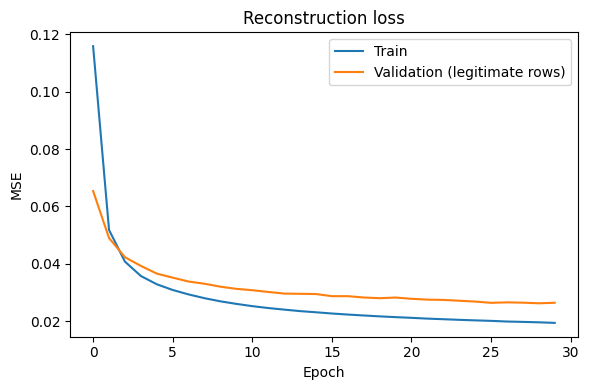

In [55]:
#plots for loss
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation (legitimate rows)')
plt.title('Reconstruction loss'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout(); plt.show()

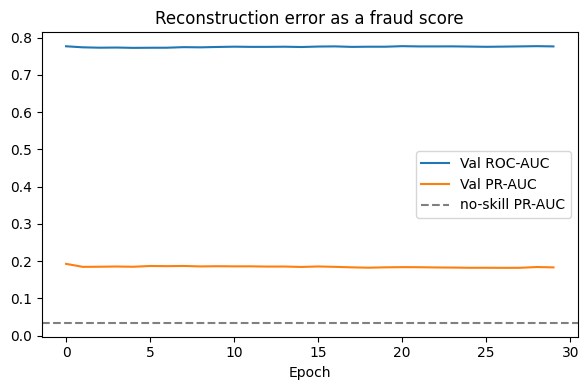

In [56]:
#plot for metrics
plt.figure(figsize=(6, 4))
plt.plot(val_rocs, label='Val ROC-AUC')
plt.plot(val_prs, label='Val PR-AUC')
plt.axhline(y_va.mean(), color='gray', ls='--', label='no-skill PR-AUC')
plt.title('Reconstruction error as a fraud score'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

#Models - GraphSAGE

In [57]:
!pip install -q torch_geometric

In [58]:
#Imports
import torch.nn as nn
from torch.optim import AdamW
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

In [59]:
#Use device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
edge_index_d = edge_index.to(device)                 # the TRAIN graph, used for train, val and test
ent_tr = torch.tensor(ent_idx[:i1]).to(device)       # each row: the 4 entity node ids of one transaction
ent_va = torch.tensor(ent_idx[i1:i2]).to(device)
ent_te = torch.tensor(ent_idx[i2:]).to(device)
y_tr_t = torch.tensor(y_tr).to(device)
y_va_t = torch.tensor(y_va).to(device)
print('graph:', edge_index_d.shape, '| entity ids train/val/test:', ent_tr.shape, ent_va.shape, ent_te.shape)

graph: torch.Size([2, 192582]) | entity ids train/val/test: torch.Size([413378, 4]) torch.Size([88581, 4]) torch.Size([88581, 4])


In [60]:
#Model
class GraphSAGEModel(nn.Module):
    def __init__(self, num_nodes, num_slots=4, dim=64, dropout=0.1):
        super(GraphSAGEModel, self).__init__()
        self.emb = nn.Embedding(num_nodes, dim)              # starting vector for every entity (row 0 = UNK)
        self.conv1 = SAGEConv(dim, dim, aggr='mean')         # layer 1: mix in direct neighbours
        self.conv2 = SAGEConv(dim, dim, aggr='mean')         # layer 2: mix in neighbours of neighbours
        self.missing = nn.Parameter(torch.zeros(num_slots, dim))   # learned vector for "this entity is missing"
        self.head = nn.Linear(num_slots * dim, 1)            # TEMPORARY head: predicts fraud, discarded later
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def node_vectors(self, edge_index):
        h = self.drop(self.emb.weight)
        h = self.relu(self.conv1(h, edge_index))
        h = self.drop(h)
        return self.conv2(h, edge_index)                     # one vector per entity, with neighbourhood context

    def txn_vectors(self, node_h, ent):
        g = node_h[ent.clamp(min=0)]                         # look up each transaction's 4 entity vectors
        miss = (ent < 0).unsqueeze(-1)
        g = torch.where(miss, self.missing.unsqueeze(0).expand_as(g), g)   # missing entity -> "missing" vector
        return g.flatten(1)                                  # glue the 4 vectors: this is g_i (4 x 64 = 256)

    def forward(self, edge_index, ent):
        g = self.txn_vectors(self.node_vectors(edge_index), ent)
        return self.head(g).squeeze(1), g

In [61]:
#Train
def train_gnn_epoch(gnn_model, gnn_optimizer, gnn_criterion, edge_index, ent_train, y_train, unk_drop=0.05):
    gnn_model.train()
    # UNK dropout: hide 5% of entities behind the UNK node so its vector learns what "unseen" looks like
    drop_mask = (torch.rand(ent_train.shape, device=ent_train.device) < unk_drop) & (ent_train >= 0)
    ent_in = torch.where(drop_mask, torch.zeros_like(ent_train), ent_train)

    logits, _ = gnn_model(edge_index, ent_in)
    loss = gnn_criterion(logits, y_train)
    gnn_optimizer.zero_grad()
    loss.backward()
    gnn_optimizer.step()
    return loss.item()

In [62]:
#Validate
def validate_gnn(gnn_model, gnn_criterion, edge_index, ent_eval, y_eval):
    gnn_model.eval()
    with torch.no_grad():
        logits, _ = gnn_model(edge_index, ent_eval)
        loss = gnn_criterion(logits, y_eval).item()
    scores = logits.cpu().numpy()
    labels = y_eval.cpu().numpy()
    return loss, roc_auc_score(labels, scores), average_precision_score(labels, scores)

In [63]:
#Build Model
gnn_dim = 64                                  # embedding size (the paper uses 64)
gnn_model = GraphSAGEModel(num_nodes, num_slots=len(ENTITY_COLS), dim=gnn_dim).to(device)
print(gnn_model)
print(f"Total trainable parameters: {sum(p.numel() for p in gnn_model.parameters() if p.requires_grad):,}")

GraphSAGEModel(
  (emb): Embedding(14166, 64)
  (conv1): SAGEConv(64, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (head): Linear(in_features=256, out_features=1, bias=True)
  (drop): Dropout(p=0.1, inplace=False)
  (relu): ReLU()
)
Total trainable parameters: 923,649


In [64]:
#Setup
gnn_epochs = 100
gnn_lr = 0.01
pos_weight = float(np.sqrt((y_tr == 0).sum() / (y_tr == 1).sum()))     # the paper's class weight: sqrt(N0/N1)
gnn_criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=device))
gnn_optimizer = AdamW(gnn_model.parameters(), lr=gnn_lr, weight_decay=1e-5)
print(f"fraud class weight = {pos_weight:.2f}")

fraud class weight = 5.24


In [65]:
#Run Training
gnn_train_losses, gnn_val_losses, gnn_val_rocs, gnn_val_prs = [], [], [], []
gnn_best_roc, gnn_best_state = -1, None

for epoch in range(gnn_epochs):
    train_loss = train_gnn_epoch(gnn_model, gnn_optimizer, gnn_criterion, edge_index_d, ent_tr, y_tr_t)
    val_loss, val_roc, val_pr = validate_gnn(gnn_model, gnn_criterion, edge_index_d, ent_va, y_va_t)
    gnn_train_losses.append(train_loss); gnn_val_losses.append(val_loss)
    gnn_val_rocs.append(val_roc); gnn_val_prs.append(val_pr)
    if val_roc > gnn_best_roc:                # keep the best epoch by validation ROC-AUC
        gnn_best_roc = val_roc
        gnn_best_state = {k: v.detach().clone() for k, v in gnn_model.state_dict().items()}
    if epoch % 10 == 0 or epoch == gnn_epochs - 1:
        print(f"Epoch [{epoch+1}/{gnn_epochs}] train {train_loss:.4f} | val {val_loss:.4f} | ROC {val_roc:.4f} | PR {val_pr:.4f}")

Epoch [1/100] train 0.7608 | val 0.4910 | ROC 0.5913 | PR 0.0458
Epoch [11/100] train 0.4513 | val 0.4573 | ROC 0.6948 | PR 0.1163
Epoch [21/100] train 0.4371 | val 0.4373 | ROC 0.7213 | PR 0.1424
Epoch [31/100] train 0.4035 | val 0.4341 | ROC 0.7470 | PR 0.1517
Epoch [41/100] train 0.3784 | val 0.4287 | ROC 0.7633 | PR 0.1570
Epoch [51/100] train 0.3594 | val 0.4347 | ROC 0.7707 | PR 0.1715
Epoch [61/100] train 0.3490 | val 0.4330 | ROC 0.7735 | PR 0.1802
Epoch [71/100] train 0.3443 | val 0.4421 | ROC 0.7721 | PR 0.1809
Epoch [81/100] train 0.3391 | val 0.4531 | ROC 0.7694 | PR 0.1808
Epoch [91/100] train 0.3383 | val 0.4562 | ROC 0.7662 | PR 0.1784
Epoch [100/100] train 0.3366 | val 0.4569 | ROC 0.7637 | PR 0.1774


In [66]:
#Best Epoch
gnn_model.load_state_dict(gnn_best_state)
best_epoch = int(np.argmax(gnn_val_rocs)) + 1
print(f"Restored best epoch ({best_epoch}). Validation ROC-AUC: {gnn_best_roc:.4f}")

Restored best epoch (55). Validation ROC-AUC: 0.7746


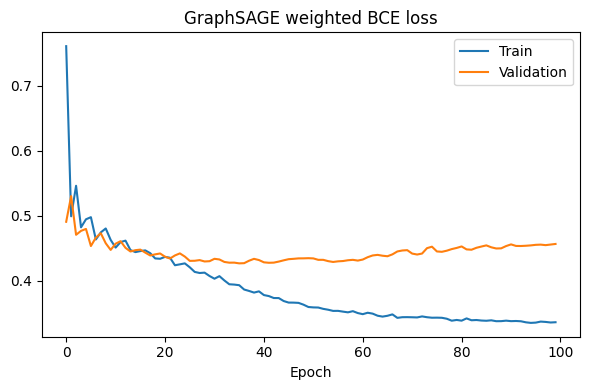

In [67]:
#Plot for loss
plt.figure(figsize=(6, 4))
plt.plot(gnn_train_losses, label='Train')
plt.plot(gnn_val_losses, label='Validation')
plt.title('GraphSAGE weighted BCE loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

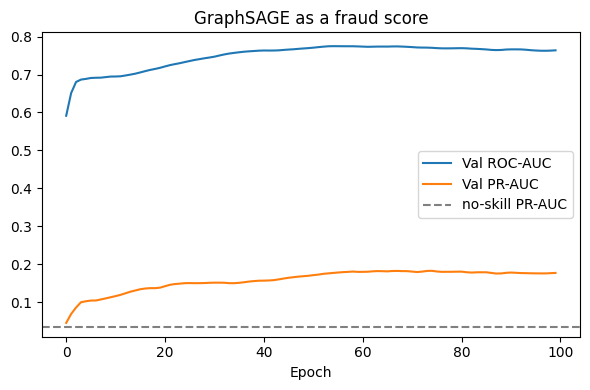

In [68]:
#Plot for metrics
plt.figure(figsize=(6, 4))
plt.plot(gnn_val_rocs, label='Val ROC-AUC')
plt.plot(gnn_val_prs, label='Val PR-AUC')
plt.axhline(y_va.mean(), color='gray', ls='--', label='no-skill PR-AUC')
plt.title('GraphSAGE as a fraud score'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

#Merge into MLP

In [69]:
#Imports
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

In [70]:
#Extract t_i (AutoEncoder)
def extract_t(model, X, device, batch_size=4096):
    model.eval()
    out = []
    with torch.no_grad():
        for k in range(0, len(X), batch_size):
            xb = torch.tensor(X[k:k + batch_size]).to(device)
            recon, z = model(xb)
            err = ((recon - xb) ** 2).mean(dim=1, keepdim=True)     # reconstruction error
            out.append(torch.cat([z, err], dim=1).cpu())             # t_i = 64-number summary + error
    return torch.cat(out).numpy()

In [71]:
#Extract t_i for every split
#the AUTOENCODER best weights restored
t_tr = extract_t(model, X_tr, device)
t_va = extract_t(model, X_va, device)
t_te = extract_t(model, X_te, device)
print('t_i shapes:', t_tr.shape, t_va.shape, t_te.shape)     # expect (rows, 65)

t_i shapes: (413378, 65) (88581, 65) (88581, 65)


In [72]:
#Extract g_i (GraphSAGE)
def extract_g(gnn_model, edge_index, ent, device):
    gnn_model.eval()
    with torch.no_grad():
        node_h = gnn_model.node_vectors(edge_index)       # one vector per entity
        g = gnn_model.txn_vectors(node_h, ent)            # glue each transaction's 4 entity vectors
    return g.cpu().numpy()

In [73]:
#Extract g_i for every split
def extract_g(gnn_model, edge_index, ent, device):
    gnn_model.eval()
    with torch.no_grad():
        node_h = gnn_model.node_vectors(edge_index)       # one vector per entity
        g = gnn_model.txn_vectors(node_h, ent)            # glue each transaction's 4 entity vectors
    return g.cpu().numpy()

In [74]:
#Standarization
def standardize(F_tr, F_va, F_te):
    mu = F_tr.mean(axis=0)
    sd = F_tr.std(axis=0)
    sd = np.where(sd == 0, 1, sd)
    f = lambda A: np.clip((A - mu) / sd, -10, 10).astype(np.float32)
    return f(F_tr), f(F_va), f(F_te)

In [75]:
#Merge features
feats = {
    'AE only (t_i)': standardize(t_tr, t_va, t_te),
    'AE + GraphSAGE (t_i || g_i)': standardize(np.hstack([t_tr, g_tr]), np.hstack([t_va, g_va]), np.hstack([t_te, g_te])),
}
for name, (a, b, c) in feats.items():
    print(f'{name:30s} train {a.shape} | val {b.shape} | test {c.shape}')     # hybrid should have 65 + 256 = 321 columns

NameError: name 'g_tr' is not defined

In [ ]:
#MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.2):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.drop(self.relu(self.fc1(x)))).squeeze(1)    # one fraud score per transaction

In [ ]:
#Train
def train_mlp_epoch(mlp, optimizer, criterion, loader, device):
    mlp.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        loss = criterion(mlp(X_batch), y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

In [ ]:
#Validate
def evaluate_mlp(mlp, criterion, loader, device):
    mlp.eval()
    scores, labels, total_loss = [], [], 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = mlp(X_batch.to(device))
            total_loss += criterion(logits, y_batch.to(device)).item() * len(y_batch)
            scores.append(logits.cpu()); labels.append(y_batch)
    scores = torch.cat(scores).numpy(); labels = torch.cat(labels).numpy()
    return total_loss / len(labels), roc_auc_score(labels, scores), average_precision_score(labels, scores)

In [ ]:
#Setup
mlp_epochs = 20
mlp_lr = 0.001
mlp_hidden = 64
mlp_batch = 1024
mlp_pos_weight = float(np.sqrt((y_tr == 0).sum() / (y_tr == 1).sum()))     # the paper's class weight
mlp_criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(mlp_pos_weight, device=device))
print(f"fraud class weight = {mlp_pos_weight:.2f}")

In [ ]:
#Setup - 2
if 'results' not in globals():
    results = {}                                   # stores each trained MLP and its history

variant = 'AE only (t_i)'                          # later change to 'AE + GraphSAGE (t_i || g_i)'
F_tr, F_va, F_te = feats[variant]
print(variant, '->', F_tr.shape)

train_loader = DataLoader(TensorDataset(torch.tensor(F_tr), torch.tensor(y_tr)), batch_size=mlp_batch, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(F_va), torch.tensor(y_va)), batch_size=4096)

mlp = MLP(F_tr.shape[1], mlp_hidden).to(device)
optimizer = AdamW(mlp.parameters(), lr=mlp_lr, weight_decay=1e-5)

In [ ]:
#train and best epoch
hist = {'train': [], 'val': [], 'roc': [], 'pr': []}
best_roc, best_state = -1, None

for epoch in range(mlp_epochs):
    train_loss = train_mlp_epoch(mlp, optimizer, mlp_criterion, train_loader, device)
    val_loss, val_roc, val_pr = evaluate_mlp(mlp, mlp_criterion, val_loader, device)
    for k, v in zip(hist, (train_loss, val_loss, val_roc, val_pr)):
        hist[k].append(v)
    if val_roc > best_roc:                         # keep the best epoch by validation ROC-AUC
        best_roc = val_roc
        best_state = {k: v.detach().clone() for k, v in mlp.state_dict().items()}
    print(f"[{variant}] Epoch [{epoch+1}/{mlp_epochs}] train {train_loss:.4f} | val {val_loss:.4f} | ROC {val_roc:.4f} | PR {val_pr:.4f}")

mlp.load_state_dict(best_state)
results[variant] = (mlp, hist)
print(f"[{variant}] best validation ROC-AUC: {best_roc:.4f}")

In [ ]:
#run baseline
F_tr, F_va, F_te = feats['AE only (t_i)']
mlp_t, hist_t = run_mlp('AE only', F_tr, F_va)

In [ ]:
#run the merge
F_tr, F_va, F_te = feats['AE + GraphSAGE (t_i || g_i)']
mlp_fused, hist_fused = run_mlp('AE + GraphSAGE', F_tr, F_va)

In [ ]:
mlp_t, hist_t = results['AE only (t_i)']
mlp_fused, hist_fused = results['AE + GraphSAGE (t_i || g_i)']

In [ ]:
#plot for loss
plt.figure(figsize=(6, 4))
plt.plot(hist_t['train'], '--', color='#378ADD', label='AE only: train')
plt.plot(hist_t['val'], color='#378ADD', label='AE only: val')
plt.plot(hist_fused['train'], '--', color='#D85A30', label='AE + GraphSAGE: train')
plt.plot(hist_fused['val'], color='#D85A30', label='AE + GraphSAGE: val')
plt.title('MLP weighted BCE loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

In [ ]:
#plot for validation
plt.figure(figsize=(6, 4))
plt.plot(hist_t['roc'], color='#378ADD', label='AE only: ROC-AUC')
plt.plot(hist_fused['roc'], color='#D85A30', label='AE + GraphSAGE: ROC-AUC')
plt.plot(hist_t['pr'], '--', color='#378ADD', label='AE only: PR-AUC')
plt.plot(hist_fused['pr'], '--', color='#D85A30', label='AE + GraphSAGE: PR-AUC')
plt.axhline(y_va.mean(), color='gray', ls=':', label='no-skill PR-AUC')
plt.title('Validation metrics'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

In [ ]:
#test
def test_scores(mlp, F_test):
    loader = DataLoader(TensorDataset(torch.tensor(F_test), torch.tensor(y_te)), batch_size=4096)
    _, roc, pr = evaluate_mlp(mlp, mlp_criterion, loader, device)
    return roc, pr

In [ ]:
#result
for name, mlp in [('AE only (t_i)', mlp_t), ('AE + GraphSAGE (t_i || g_i)', mlp_fused)]:
    roc, pr = test_scores(mlp, feats[name][2])
    print(f"{name:30s} TEST  ROC-AUC {roc:.4f} | PR-AUC {pr:.4f}")
print(f"(no-skill PR-AUC = {y_te.mean():.4f})")